# RQ1:How can students be grouped based on their online learning behaviors, and what characterizes each cluster?

In [1]:

#Import Libraries

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE

In [2]:

sns.set(style="whitegrid", context="talk")

In [3]:

#  Load Data

studentVle = pd.read_csv("studentVle.csv")
studentInfo = pd.read_csv("studentInfo.csv")
courses = pd.read_csv("courses.csv")
assessments = pd.read_csv("assessments.csv")

In [4]:

# Feature Engineering per student
# Aggregate clicks and active days
agg = studentVle.groupby(['code_module','code_presentation','id_student']).agg(
    total_clicks=('sum_click','sum'),
    num_active_days=('date','nunique'),
    first_active_day=('date','min'),
    last_active_day=('date','max')
).reset_index()

In [5]:
# Average clicks per active day
agg['avg_clicks_per_active_day'] = agg['total_clicks'] / agg['num_active_days'].replace(0,np.nan)

# Number of unique sites clicked
site_counts = studentVle.groupby(['code_module','code_presentation','id_student'])['id_site'].nunique().reset_index().rename(columns={'id_site':'num_unique_sites'})
agg = agg.merge(site_counts, on=['code_module','code_presentation','id_student'], how='left')

# Merge module length
courses_lookup = courses.set_index(['code_module','code_presentation'])['module_presentation_length'].to_dict()
agg['module_length_days'] = agg.apply(lambda r: courses_lookup.get((r['code_module'], r['code_presentation']), np.nan), axis=1)

# Days inactive
agg['days_inactive'] = (agg['module_length_days'] - agg['num_active_days']).clip(lower=0)

# Last week engagement
studentVle = studentVle.merge(courses[['code_module','code_presentation','module_presentation_length']], on=['code_module','code_presentation'], how='left')
studentVle['last_week_flag'] = studentVle['date'] >= (studentVle['module_presentation_length'] - 7)
last_week = studentVle[studentVle['last_week_flag']].groupby(['code_module','code_presentation','id_student'])['sum_click'].sum().reset_index().rename(columns={'sum_click':'last_week_clicks'})
agg = agg.merge(last_week, on=['code_module','code_presentation','id_student'], how='left')
agg['last_week_clicks'] = agg['last_week_clicks'].fillna(0)

# Engagement before final exam
exam_dates = assessments[assessments['assessment_type'].str.contains('Exam', case=False)]
exam_lookup = {(row['code_module'], row['code_presentation']): row['date'] for _,row in exam_dates.iterrows()}
studentVle['exam_date'] = studentVle.apply(lambda r: exam_lookup.get((r['code_module'],r['code_presentation']), r['module_presentation_length']), axis=1)
studentVle['before_exam_flag'] = (studentVle['date'] >= (studentVle['exam_date'] - 7)) & (studentVle['date'] < studentVle['exam_date'])
before_exam = studentVle[studentVle['before_exam_flag']].groupby(['code_module','code_presentation','id_student'])['sum_click'].sum().reset_index().rename(columns={'sum_click':'before_exam_clicks'})
agg = agg.merge(before_exam, on=['code_module','code_presentation','id_student'], how='left')
agg['before_exam_clicks'] = agg['before_exam_clicks'].fillna(0)

# Proportion of active days
agg['prop_active_days'] = agg['num_active_days'] / agg['module_length_days'].replace(0,np.nan)
agg[['avg_clicks_per_active_day','prop_active_days']] = agg[['avg_clicks_per_active_day','prop_active_days']].fillna(0)


In [6]:

#Merge with studentInfo (final_result)

df = agg.merge(studentInfo, on=['code_module','code_presentation','id_student'], how='left')
df = df[df['final_result'].notna()].copy()  # keep valid students

# Encode final_result for ARI/NMI
le = LabelEncoder()
df['final_result_label'] = le.fit_transform(df['final_result'].astype(str))

In [7]:

# Prepare Features for Clustering

feature_cols = ['total_clicks','avg_clicks_per_active_day','num_active_days','days_inactive',
                'num_unique_sites','last_week_clicks','before_exam_clicks','prop_active_days']
X = df[feature_cols].fillna(0)
# Compute skewness for selected features
skew_values = X[['total_clicks','last_week_clicks','before_exam_clicks','num_unique_sites']].skew()
print(skew_values)
# Optional log-transform skewed features
for c in ['last_week_clicks','before_exam_clicks']:
    X[c] = np.log1p(X[c])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

total_clicks           2.940509
last_week_clicks      52.454350
before_exam_clicks     5.631191
num_unique_sites       1.378602
dtype: float64


In [8]:

# K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"KMeans silhouette for k=3: {sil:.3f}")

KMeans silhouette for k=3: 0.365


In [9]:

# DBSCAN Clustering (outlier detection)

db = DBSCAN(eps=0.8, min_samples=8)
df['dbscan_cluster'] = db.fit_predict(X_scaled)
print("DBSCAN unique clusters:", np.unique(df['dbscan_cluster']))

DBSCAN unique clusters: [-1  0  1  2  3  4  5]


In [10]:

# Evaluate Clusters

sil = silhouette_score(X_scaled, df['kmeans_cluster'])
ari = adjusted_rand_score(df['final_result_label'], df['kmeans_cluster'])
nmi = normalized_mutual_info_score(df['final_result_label'], df['kmeans_cluster'])
print(f"k means Silhouette: {sil:.3f}, ARI: {ari:.3f}, NMI: {nmi:.3f}")

k means Silhouette: 0.365, ARI: 0.114, NMI: 0.171


In [11]:

# Cluster Interpretation

# Feature summary per cluster
print("\nCluster Feature Summary:")
print(df.groupby('kmeans_cluster')[feature_cols].mean())

# Cluster vs final_result table
print("\nCluster vs Final Result:")
print(pd.crosstab(df['kmeans_cluster'], df['final_result']))


Cluster Feature Summary:
                total_clicks  avg_clicks_per_active_day  num_active_days  \
kmeans_cluster                                                             
0                1753.328400                  21.162574        88.371300   
1                 379.441984                  15.537322        24.637018   
2                4851.153759                  29.771885       165.232062   

                days_inactive  num_unique_sites  last_week_clicks  \
kmeans_cluster                                                      
0                  167.951737         90.867010          2.483269   
1                  231.533492         33.501830          0.142875   
2                   90.361333        160.617882         12.723235   

                before_exam_clicks  prop_active_days  
kmeans_cluster                                        
0                        65.330867          0.344760  
1                         3.517875          0.096175  
2                       139

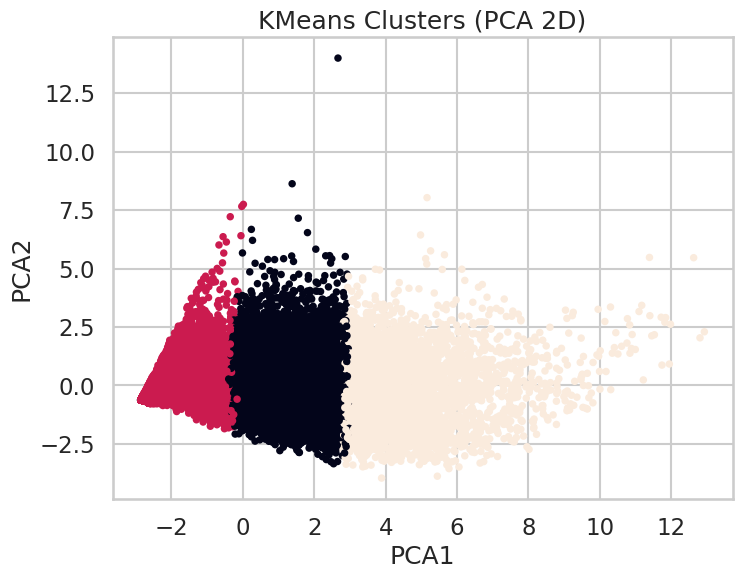

In [12]:

#Visualizations

#PCA Scatter
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans_cluster'], s=15)
plt.title("KMeans Clusters (PCA 2D)")
plt.xlabel("PCA1"); plt.ylabel("PCA2")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


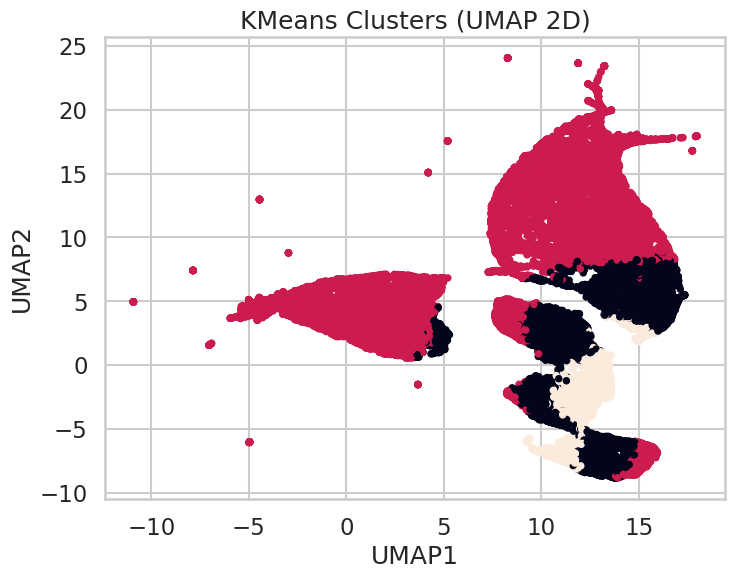

In [13]:
# UMAP Scatter
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=df['kmeans_cluster'], s=15)
plt.title("KMeans Clusters (UMAP 2D)")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.show()

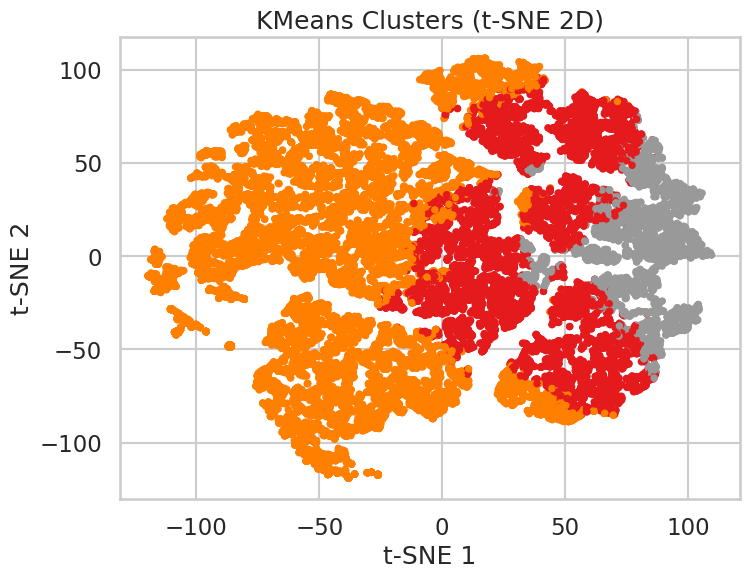

In [14]:
# t-SNE 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['kmeans_cluster'], cmap='Set1', s=15)
plt.title("KMeans Clusters (t-SNE 2D)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()



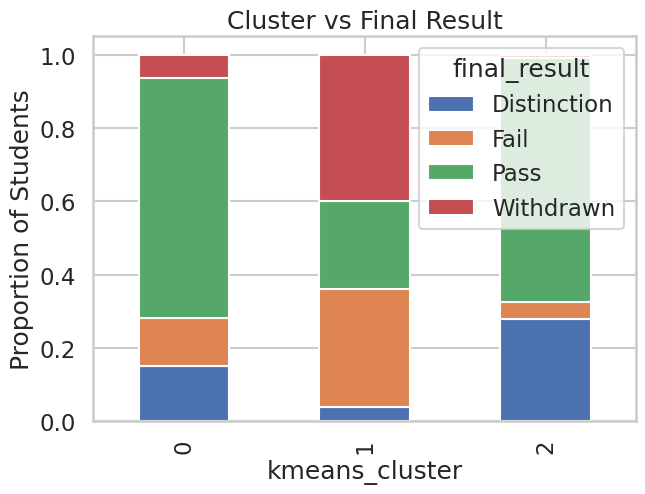

In [15]:
# Cluster vs final_result proportion
cluster_result = pd.crosstab(df['kmeans_cluster'], df['final_result'], normalize='index')
cluster_result.plot(kind='bar', stacked=True, figsize=(7,5))
plt.title("Cluster vs Final Result")
plt.ylabel("Proportion of Students")
plt.show()

# RQ2: What is the relationship between engagement level and students’ final results, and is this relationship statistically significant?

In [26]:

!pip install scikit-posthocs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, kruskal
import scikit_posthocs as sp
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid", context="talk")


In [17]:
# Load files
courses = pd.read_csv("courses.csv")
assessments = pd.read_csv("assessments.csv")
studentVle = pd.read_csv("studentVle.csv")
studentInfo = pd.read_csv("studentInfo.csv")

In [18]:
# cleaning
studentVle['sum_click'] = pd.to_numeric(studentVle['sum_click'], errors='coerce').fillna(0).astype(int)
studentVle['date'] = pd.to_numeric(studentVle['date'], errors='coerce').fillna(0).astype(int)
# Determine module length column
courses_len_col = 'length' if 'length' in courses.columns else ('module_presentation_length' if 'module_presentation_length' in courses.columns else courses.columns[-1])
courses_lookup = courses.set_index(['code_module','code_presentation'])[courses_len_col].to_dict()

# Get final exam dates
exam_mask = assessments['assessment_type'].str.contains('Exam', case=False, na=False)
exam_dates = assessments[exam_mask].copy()
exam_lookup = {(r['code_module'], r['code_presentation']): r['date'] for _, r in exam_dates.iterrows()}

In [19]:
# Feature engineering per student
# Aggregate core engagement features
agg = studentVle.groupby(['code_module','code_presentation','id_student']).agg(
    total_clicks = ('sum_click','sum'),
    num_active_days = ('date','nunique'),
    first_active_day = ('date','min'),
    last_active_day = ('date','max'),
    num_unique_sites = ('id_site','nunique')
).reset_index()
agg['avg_clicks_per_active_day'] = agg['total_clicks'] / agg['num_active_days'].replace(0,np.nan)

# Module length & days inactive
agg['module_length_days'] = agg.apply(lambda r: courses_lookup.get((r['code_module'], r['code_presentation']), np.nan), axis=1)
agg['days_inactive'] = (agg['module_length_days'] - agg['num_active_days']).clip(lower=0)

# Compute week numbers
studentVle = studentVle.merge(courses[['code_module','code_presentation', courses_len_col]],
                              on=['code_module','code_presentation'], how='left')
studentVle = studentVle.rename(columns={courses_len_col:'module_length_days'})
studentVle['week'] = (studentVle['date'] // 7).astype(int)

# Last week number per module
module_last_week = (
    studentVle.groupby(['code_module','code_presentation'])
    .apply(lambda g: int(np.floor((g['module_length_days'].iloc[0]-1)/7)) if not pd.isna(g['module_length_days'].iloc[0]) else int(g['week'].max()))
    .rename('last_week_number').reset_index()
)
studentVle = studentVle.merge(module_last_week, on=['code_module','code_presentation'], how='left')

# Last-week clicks (only for students with activity)
last_week_df = (
    studentVle[studentVle['week'] == studentVle['last_week_number']]
    .groupby(['code_module','code_presentation','id_student'])['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'last_week_clicks'})
)
agg = agg.merge(last_week_df, on=['code_module','code_presentation','id_student'], how='left')
agg['last_week_clicks'] = agg['last_week_clicks'].fillna(0).astype(int)

# Before-exam clicks (only for students with activity)
def compute_exam_week(row):
    exam_date = exam_lookup.get((row['code_module'], row['code_presentation']), np.nan)
    if not pd.isna(exam_date):
        return int(exam_date // 7)
    else:
        return int(row['last_week_number'])

studentVle['exam_week'] = studentVle.apply(compute_exam_week, axis=1)
studentVle['before_exam_flag'] = (studentVle['week'] >= (studentVle['exam_week'] - 1)) & (studentVle['week'] < studentVle['exam_week'])
before_exam_df = (
    studentVle[studentVle['before_exam_flag']]
    .groupby(['code_module','code_presentation','id_student'])['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'before_exam_clicks'})
)
agg = agg.merge(before_exam_df, on=['code_module','code_presentation','id_student'], how='left')
agg['before_exam_clicks'] = agg['before_exam_clicks'].fillna(0).astype(int)

# Proportion of active days
agg['prop_active_days'] = agg['num_active_days'] / agg['module_length_days'].replace(0,np.nan)
agg[['avg_clicks_per_active_day','prop_active_days']] = agg[['avg_clicks_per_active_day','prop_active_days']].fillna(0)


In [20]:
# Merge with studentInfo for final_result
master = agg.merge(studentInfo, on=['code_module','code_presentation','id_student'], how='left')
master = master[master['final_result'].notna()].copy()
master['final_result'] = master['final_result'].astype(str)

In [21]:
# Select features for analysis
engagement_features = [
    'total_clicks',
    'avg_clicks_per_active_day',
    'num_active_days',
    'num_unique_sites',
    'last_week_clicks',
    'before_exam_clicks',
    'prop_active_days'
]

master = master.dropna(subset=engagement_features, how='all')

In [22]:
# Descriptive statistics
print("\n Median engagement per final_result \n")
print(master.groupby('final_result')[['total_clicks','avg_clicks_per_active_day',
                                      'num_active_days','num_unique_sites','prop_active_days']].median().round(2))

# For last-week and before-exam, only consider students with activity
print("\n Median last_week_clicks (only students active in last week) \n")
last_week_active = master[master['last_week_clicks'] > 0]
print(last_week_active.groupby('final_result')['last_week_clicks'].median().round(2))

print("\n Median before_exam_clicks (only students active before exam)\n")
before_exam_active = master[master['before_exam_clicks'] > 0]
print(before_exam_active.groupby('final_result')['before_exam_clicks'].median().round(2))


 Median engagement per final_result 

              total_clicks  avg_clicks_per_active_day  num_active_days  \
final_result                                                             
Distinction         1896.0                      19.36            103.0   
Fail                 353.0                      14.64             24.0   
Pass                1343.0                      17.82             78.0   
Withdrawn            221.5                      14.44             15.0   

              num_unique_sites  prop_active_days  
final_result                                      
Distinction               82.0              0.40  
Fail                      34.0              0.10  
Pass                      73.5              0.30  
Withdrawn                 25.0              0.06  

 Median last_week_clicks (only students active in last week) 

final_result
Distinction    4.0
Fail           2.0
Pass           3.0
Withdrawn      7.0
Name: last_week_clicks, dtype: float64

 Median before_ex

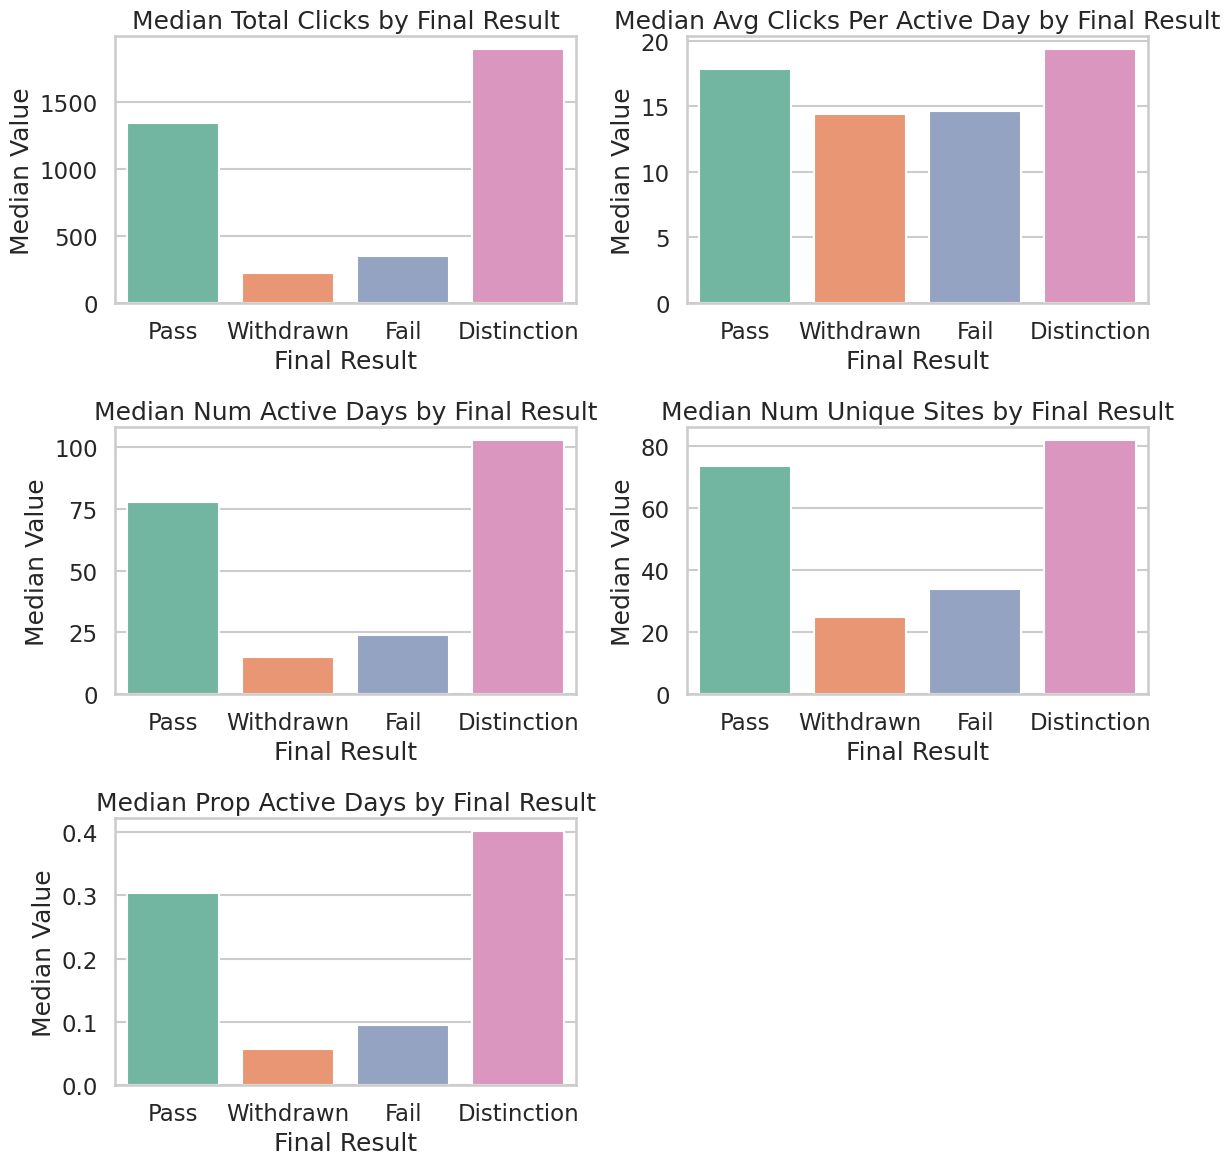

In [23]:
# Engagement features to plot separately
features = ['total_clicks','avg_clicks_per_active_day','num_active_days','num_unique_sites','prop_active_days']

# Create a figure with multiple subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))  # 3x2 grid for 5 plots
axes = axes.flatten()  # Flatten to easily index

# Loop over features and axes
for i, feature in enumerate(features):
    sns.barplot(
        data=master,
        x='final_result',
        y=feature,
        estimator=np.median,
        ci=None,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f'Median {feature.replace("_"," ").title()} by Final Result')
    axes[i].set_ylabel('Median Value')
    axes[i].set_xlabel('Final Result')

# Remove the empty subplot if features < number of subplots
if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

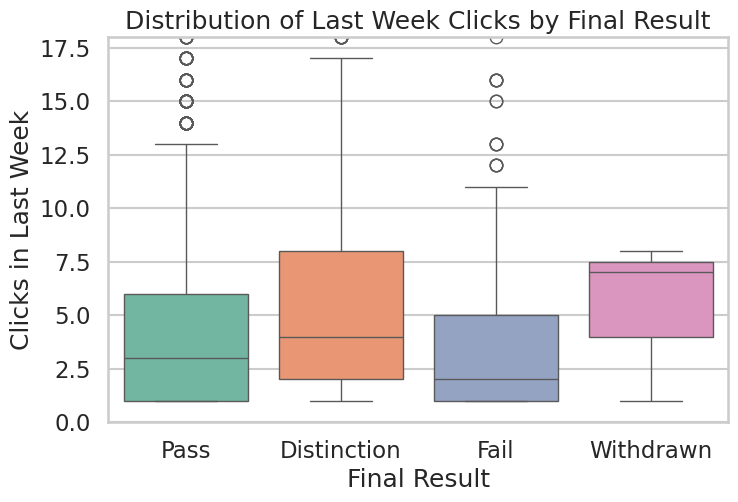

In [24]:
# Filter students with >0 clicks in last week
last_week_active = master[master['last_week_clicks']>0]

plt.figure(figsize=(8,5))
sns.boxplot(data=last_week_active, x='final_result', y='last_week_clicks', palette='Set2')
plt.title('Distribution of Last Week Clicks by Final Result')
plt.ylabel('Clicks in Last Week')
plt.xlabel('Final Result')
plt.ylim(0, last_week_active['last_week_clicks'].quantile(0.95))  # remove extreme outliers for visibility
plt.show()


In [25]:
# Automatic stats test per feature

def run_auto_stats_simple(feature, df, filter_active=False):
    print(f"\n=== Feature: {feature} ===")

    # Filter active students if required
    if filter_active:
        df = df[df[feature] > 0]

    categories = df['final_result'].unique()
    groups = [df[df['final_result'] == cat][feature].values for cat in categories]

    # Shapiro test per group (normality)
    normal = True
    for cat, vals in zip(categories, groups):
        if len(vals) > 3:
            stat, p = shapiro(vals)
            print(f"Shapiro ({cat}, n={len(vals)}): p={p:.3e}, normal? {p>0.05}")
            if p <= 0.05:
                normal = False

    # Levene test for equal variance
    stat, p_var = levene(*groups)
    equal_var = p_var > 0.05
    print(f"Levene p = {p_var:.3e} -> equal variances? {equal_var}")

    # Decide which test to run
    if normal and equal_var:
        # Parametric ANOVA
        stat, p_anova = f_oneway(*groups)
        print(f"ANOVA p = {p_anova:.3e}")
        if p_anova < 0.05:
            print("Significant difference found (ANOVA)")
        else:
            print("No significant difference found (ANOVA)")
    else:
        # Non-parametric Kruskal-Wallis
        stat, p_kw = kruskal(*groups)
        print(f"Kruskal-Wallis p = {p_kw:.3e}")
        if p_kw < 0.05:
            print("Significant difference found (Kruskal-Wallis)")
        else:
            print("No significant difference found (Kruskal-Wallis)")

# Run for core engagement features
for feat in ['total_clicks','avg_clicks_per_active_day','num_active_days','num_unique_sites','prop_active_days']:
    run_auto_stats_simple(feat, master)

# Run for last-week and before-exam clicks (only active students)
for feat, filter_active in [('last_week_clicks', True), ('before_exam_clicks', True)]:
    run_auto_stats_simple(feat, master, filter_active=filter_active)



=== Feature: total_clicks ===
Shapiro (Pass, n=12358): p=2.505e-84, normal? False
Shapiro (Withdrawn, n=7168): p=1.224e-84, normal? False
Shapiro (Fail, n=6678): p=7.125e-80, normal? False
Shapiro (Distinction, n=3024): p=5.002e-50, normal? False
Levene p = 0.000e+00 -> equal variances? False
Kruskal-Wallis p = 0.000e+00
Significant difference found (Kruskal-Wallis)

=== Feature: avg_clicks_per_active_day ===
Shapiro (Pass, n=12358): p=3.058e-71, normal? False
Shapiro (Withdrawn, n=7168): p=3.835e-66, normal? False
Shapiro (Fail, n=6678): p=1.217e-61, normal? False
Shapiro (Distinction, n=3024): p=7.977e-37, normal? False
Levene p = 4.295e-03 -> equal variances? False
Kruskal-Wallis p = 3.122e-267
Significant difference found (Kruskal-Wallis)

=== Feature: num_active_days ===
Shapiro (Pass, n=12358): p=4.651e-54, normal? False
Shapiro (Withdrawn, n=7168): p=1.764e-70, normal? False
Shapiro (Fail, n=6678): p=8.064e-65, normal? False
Shapiro (Distinction, n=3024): p=7.840e-25, normal? F

# RQ3:
How do demographic factors (gender, age band, region, disability) influence learning behavior and academic performance, and are these differences statistically significant?

In [27]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, kruskal
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [28]:
# LOAD DATA
student_info = pd.read_csv('studentInfo.csv')
student_registration = pd.read_csv('studentRegistration.csv')
student_assessment = pd.read_csv('studentAssessment.csv')
student_vle = pd.read_csv('studentVle.csv')

In [29]:
# PREPARE AND MERGE DATA
# Merge student info with registration
df = student_registration.merge(
    student_info,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

# Assessment averages
assessment_avg = student_assessment.groupby('id_student').agg({
    'score': ['mean', 'std', 'count']
}).reset_index()
assessment_avg.columns = ['id_student', 'avg_score', 'score_std', 'num_assessments']

# VLE engagement
vle_engagement = student_vle.groupby('id_student').agg({
    'sum_click': 'sum',
    'date': 'count'
}).reset_index()
vle_engagement.columns = ['id_student', 'total_clicks', 'num_vle_interactions']

# Merge all together
df = df.merge(assessment_avg, on='id_student', how='left')
df = df.merge(vle_engagement, on='id_student', how='left')

# Fill missing
df['avg_score'] = df['avg_score'].fillna(0)
df['total_clicks'] = df['total_clicks'].fillna(0)
df['num_vle_interactions'] = df['num_vle_interactions'].fillna(0)

# Derived feature
df['clicks_per_interaction'] = df['total_clicks'] / (df['num_vle_interactions'] + 1)

DEMOGRAPHIC IMPACT ANALYSIS - STATISTICAL TESTS
--------------------------------------------------------------------------------
ANALYZING: GENDER
--------------------------------------------------------------------------------

1. Chi-Square Test: gender vs Final Result
   Chi-square = 16.5301
   P-value = 0.000883
   Cramér's V = 0.0225

2. Kruskal-Wallis: gender vs avg_score
   H-statistic = 7.1864
   P-value = 0.007346
   Effect size (epsilon²) = 0.0002

2. Kruskal-Wallis: gender vs total_clicks
   H-statistic = 1286.0767
   P-value = 0.000000
   Effect size (epsilon²) = 0.0394

2. Kruskal-Wallis: gender vs num_assessments
   H-statistic = 68.8700
   P-value = 0.000000
   Effect size (epsilon²) = 0.0025


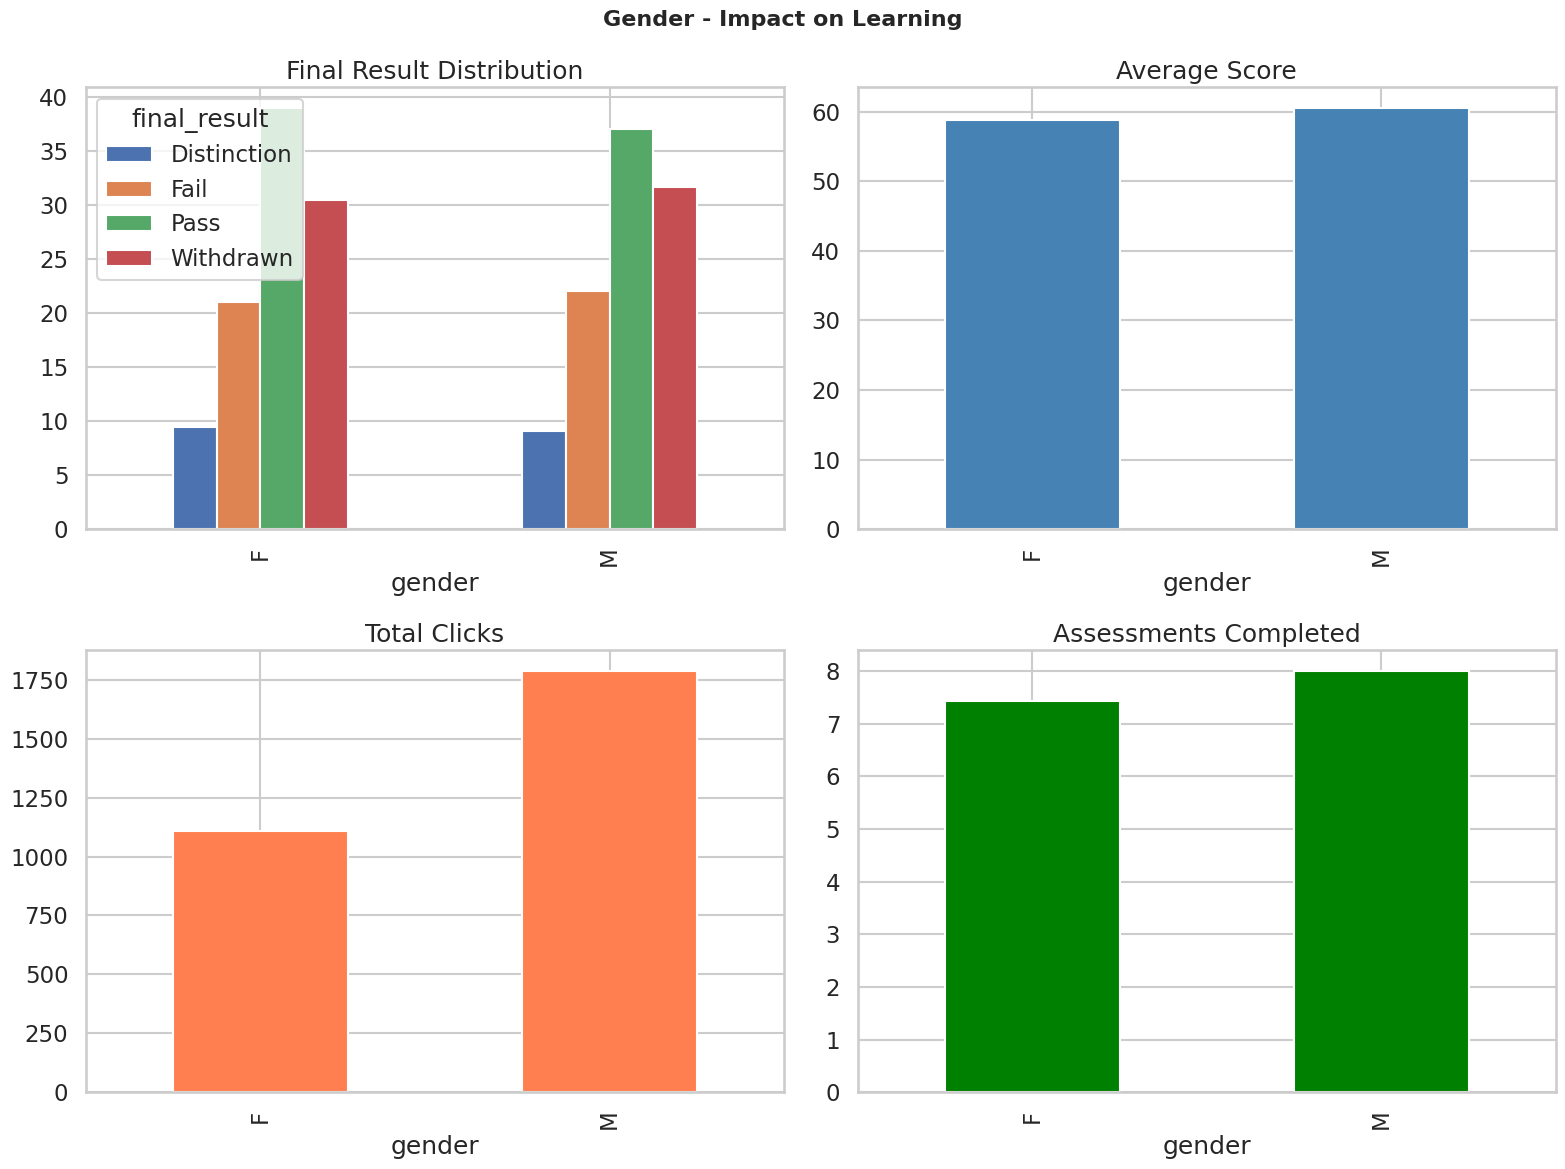

ANALYZING: AGE_BAND
--------------------------------------------------------------------------------

1. Chi-Square Test: age_band vs Final Result
   Chi-square = 222.6508
   P-value = 0.000000
   Cramér's V = 0.0584

2. Kruskal-Wallis: age_band vs avg_score
   H-statistic = 237.3067
   P-value = 0.000000
   Effect size (epsilon²) = 0.0072

2. Kruskal-Wallis: age_band vs total_clicks
   H-statistic = 420.5592
   P-value = 0.000000
   Effect size (epsilon²) = 0.0128

2. Kruskal-Wallis: age_band vs num_assessments
   H-statistic = 9.8469
   P-value = 0.007274
   Effect size (epsilon²) = 0.0003


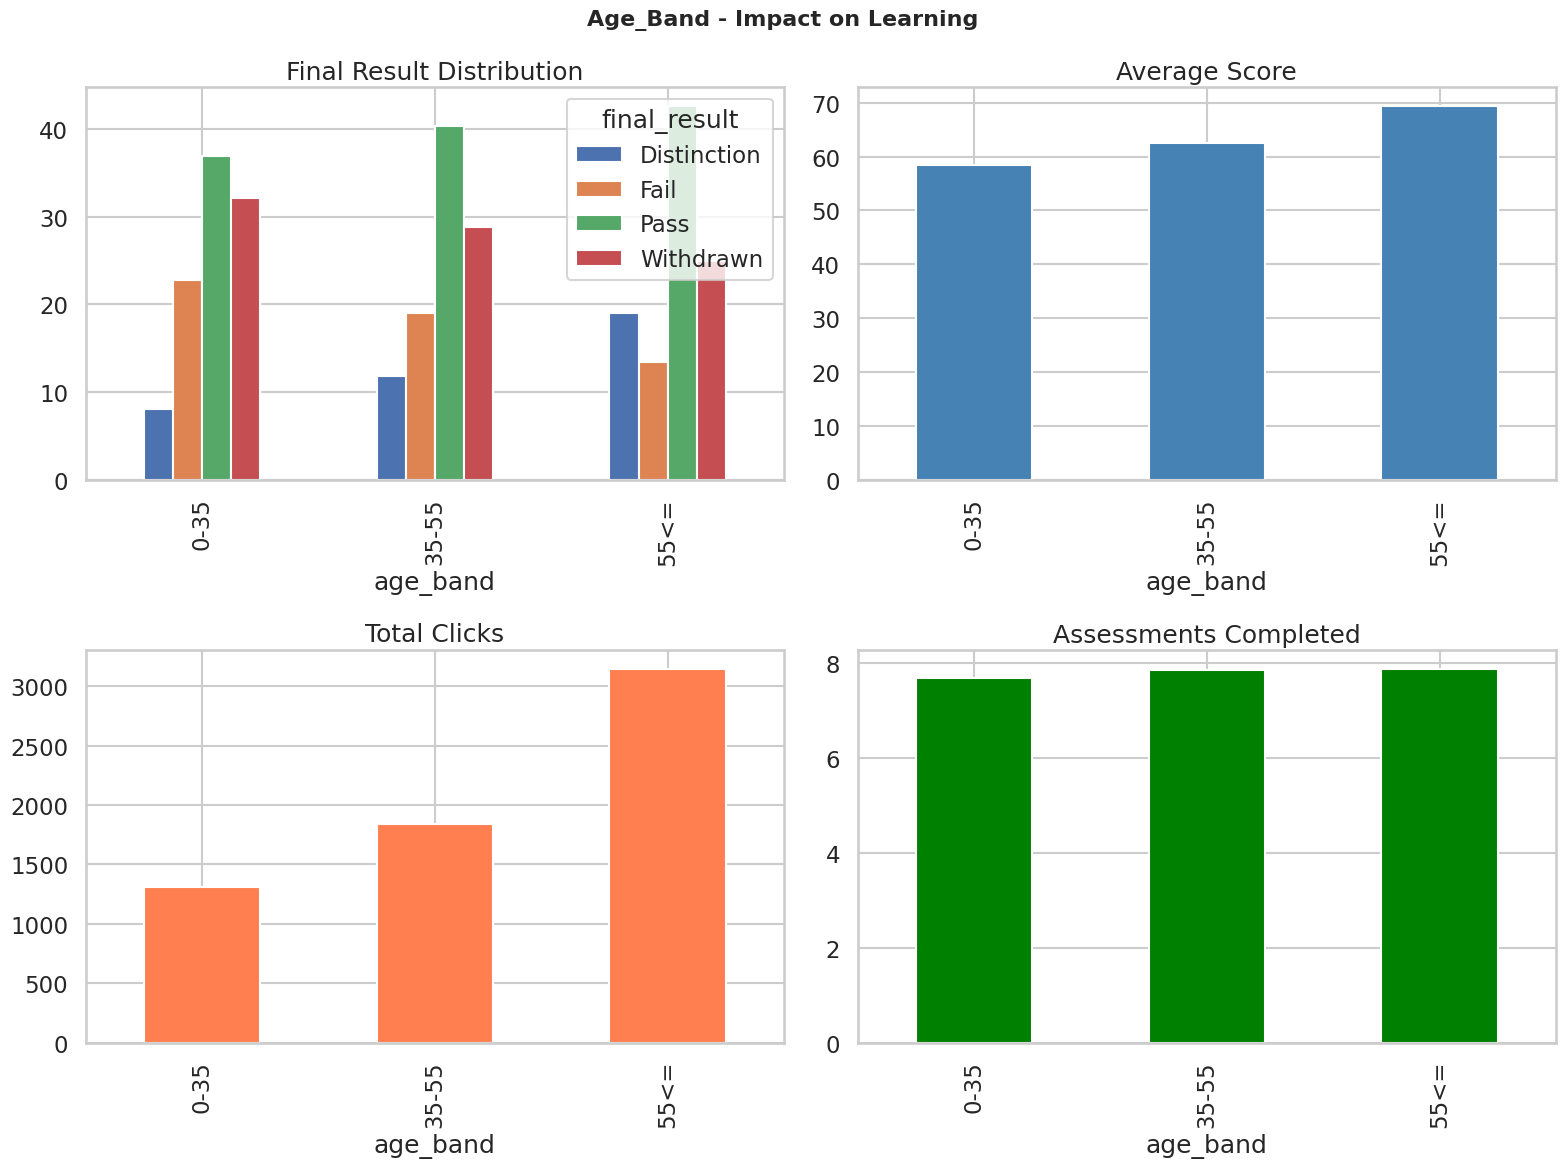

ANALYZING: REGION
--------------------------------------------------------------------------------

1. Chi-Square Test: region vs Final Result
   Chi-square = 449.7151
   P-value = 0.000000
   Cramér's V = 0.0678

2. Kruskal-Wallis: region vs avg_score
   H-statistic = 279.8189
   P-value = 0.000000
   Effect size (epsilon²) = 0.0082

2. Kruskal-Wallis: region vs total_clicks
   H-statistic = 330.1080
   P-value = 0.000000
   Effect size (epsilon²) = 0.0098

2. Kruskal-Wallis: region vs num_assessments
   H-statistic = 82.3375
   P-value = 0.000000
   Effect size (epsilon²) = 0.0026


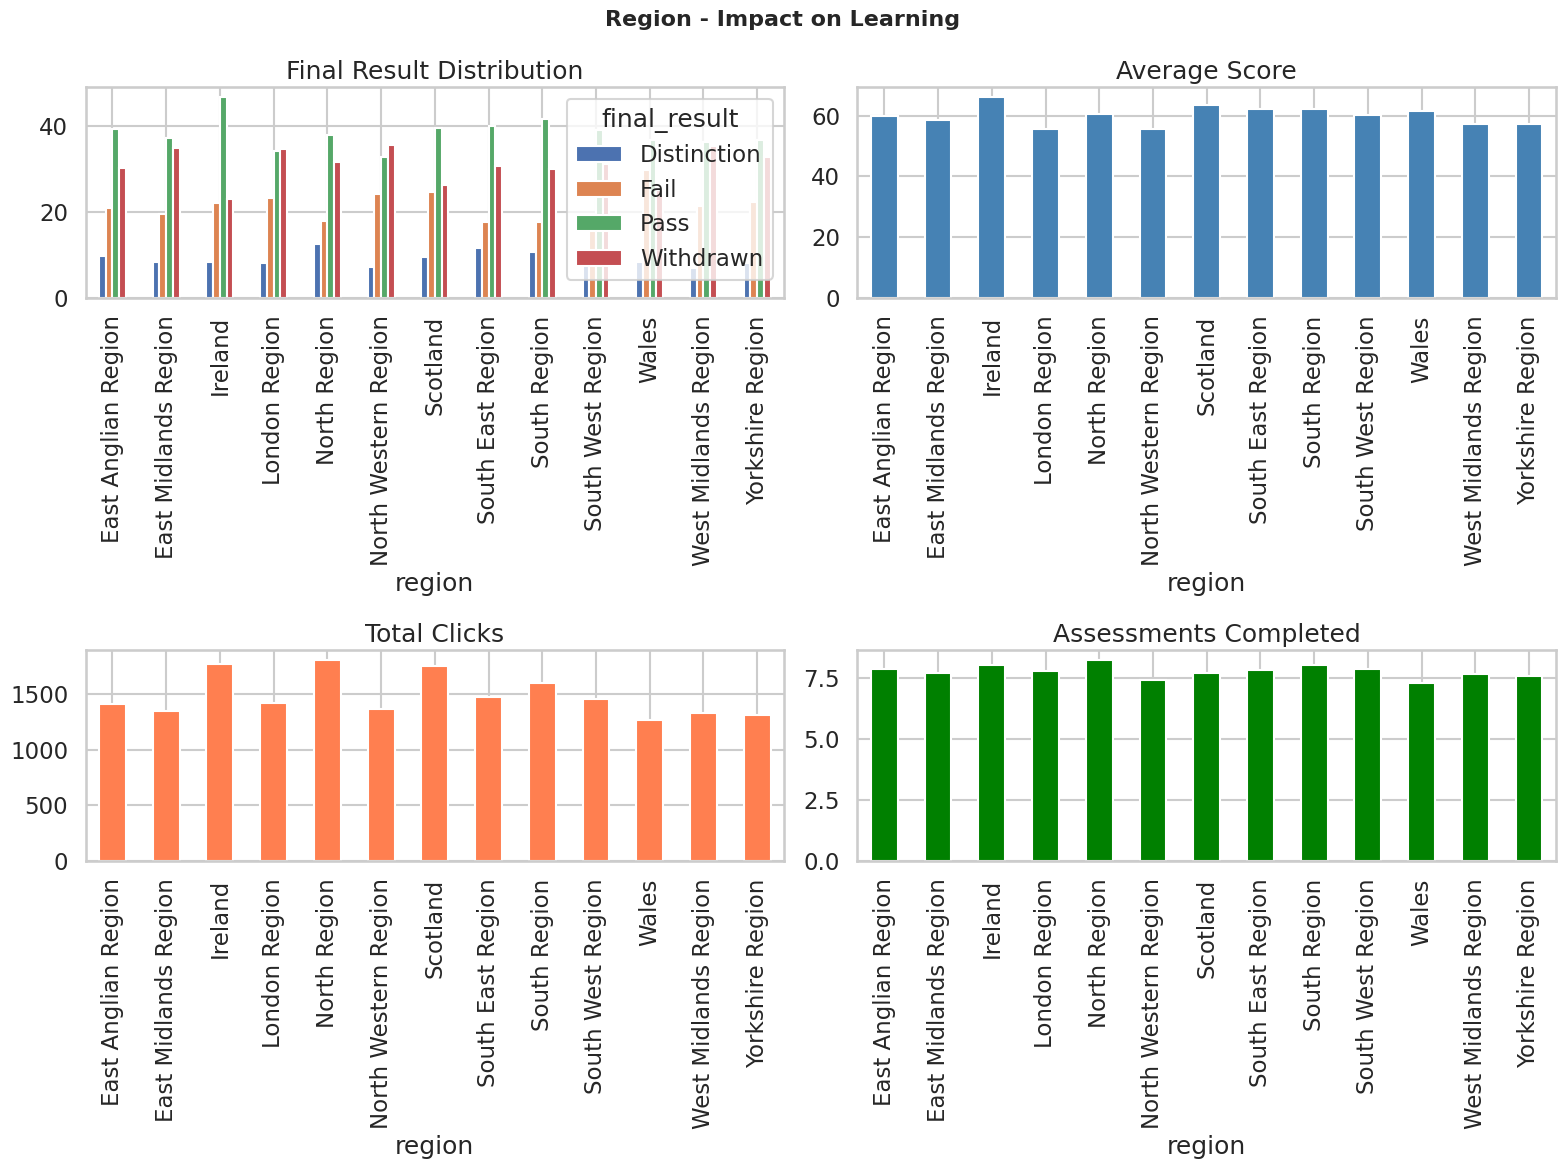

ANALYZING: DISABILITY
--------------------------------------------------------------------------------

1. Chi-Square Test: disability vs Final Result
   Chi-square = 138.4540
   P-value = 0.000000
   Cramér's V = 0.0652

2. Kruskal-Wallis: disability vs avg_score
   H-statistic = 67.8458
   P-value = 0.000000
   Effect size (epsilon²) = 0.0021

2. Kruskal-Wallis: disability vs total_clicks
   H-statistic = 38.1670
   P-value = 0.000000
   Effect size (epsilon²) = 0.0011

2. Kruskal-Wallis: disability vs num_assessments
   H-statistic = 20.3583
   P-value = 0.000006
   Effect size (epsilon²) = 0.0007


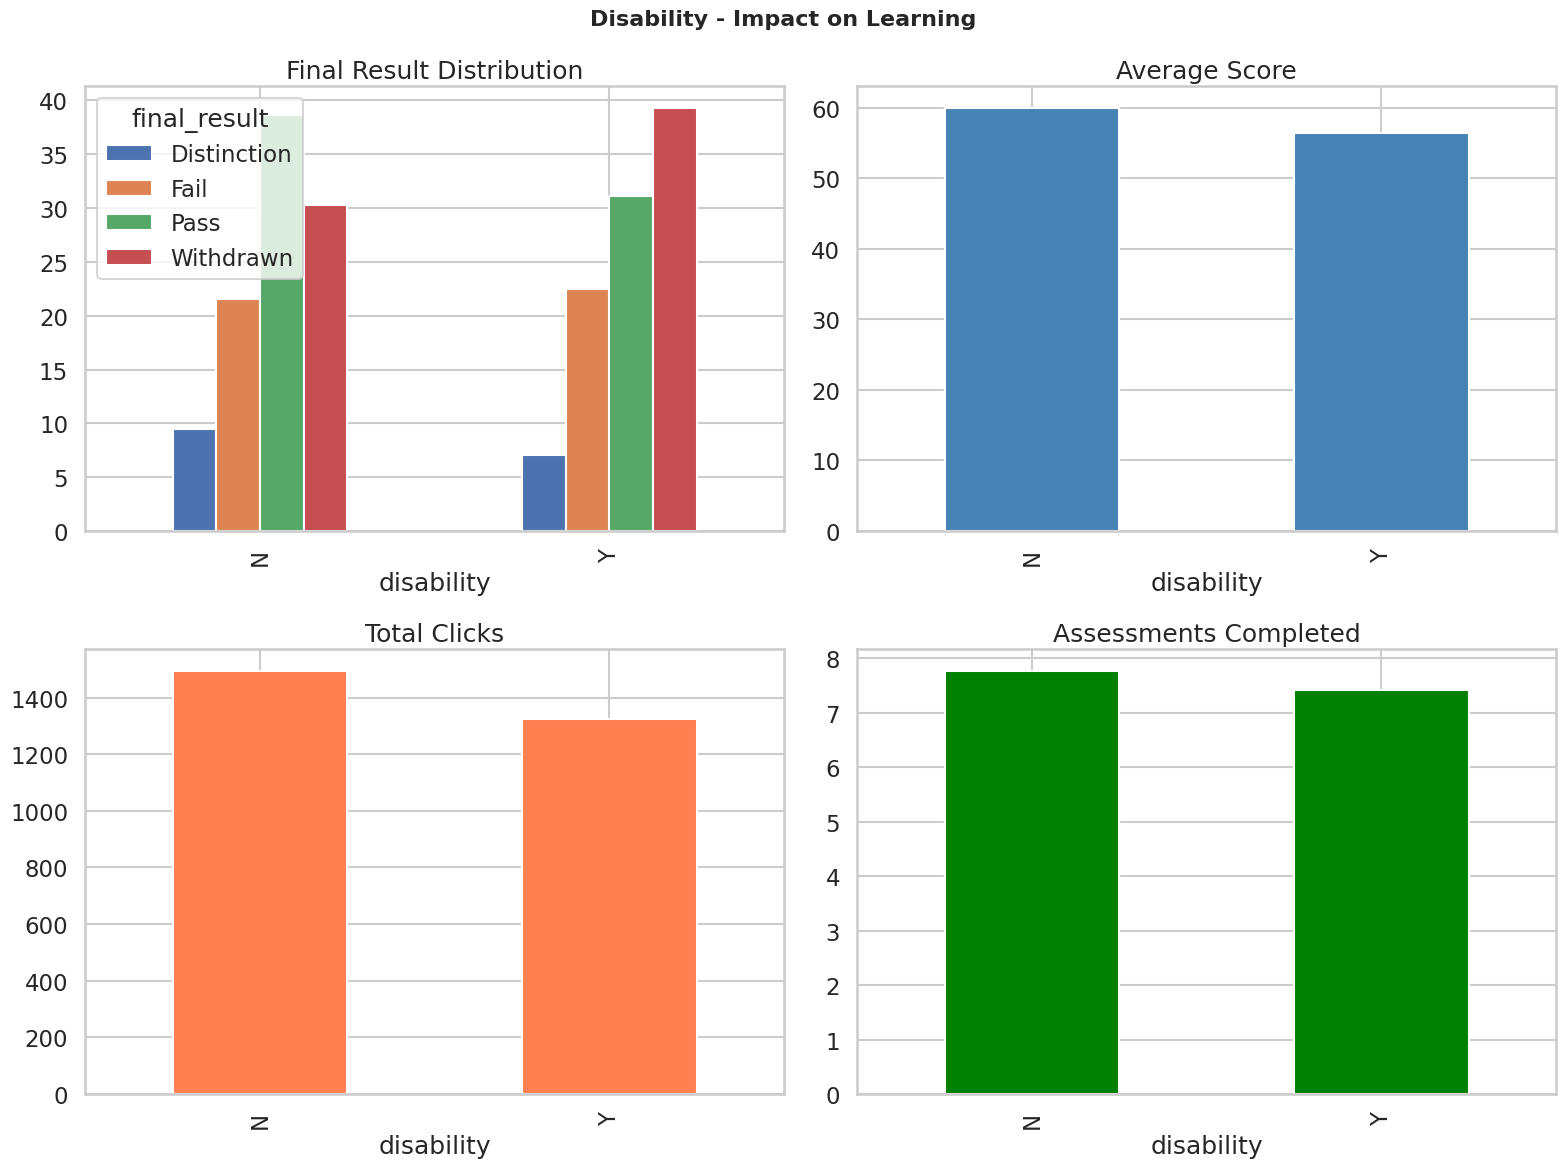

In [30]:
# STATISTICAL TESTS
demographic_vars = ['gender', 'age_band', 'region', 'disability']
continuous_vars = ['avg_score', 'total_clicks', 'num_assessments']

results = {}

print("DEMOGRAPHIC IMPACT ANALYSIS - STATISTICAL TESTS")
print("-"*80)

for demo_var in demographic_vars:
    if demo_var not in df.columns:
        print(f"\nWarning: {demo_var} missing. Skipping...")
        continue


    print(f"ANALYZING: {demo_var.upper()}")
    print(f"{'-'*80}")

    results[demo_var] = {}

    # CHI-SQUARE TEST
    print(f"\n1. Chi-Square Test: {demo_var} vs Final Result")
    contingency_table = pd.crosstab(df[demo_var], df['final_result'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"   Chi-square = {chi2:.4f}")
    print(f"   P-value = {p_value:.6f}")
    print(f"   Cramér's V = {cramers_v:.4f}")

    # Save result
    results[demo_var]['final_result'] = {
        'chi2': chi2,
        'p_value': p_value,
        'cramers_v': cramers_v,
        'contingency_table': contingency_table
    }

    # KRUSKAL–WALLIS FOR CONTINUOUS VARS
    for cont_var in continuous_vars:
        print(f"\n2. Kruskal-Wallis: {demo_var} vs {cont_var}")

        groups = [group[cont_var].dropna() for name, group in df.groupby(demo_var)]
        h_stat, p_val = kruskal(*groups)

        n = sum(len(g) for g in groups)
        k = len(groups)
        epsilon_sq = (h_stat - k + 1) / (n - k)

        print(f"   H-statistic = {h_stat:.4f}")
        print(f"   P-value = {p_val:.6f}")
        print(f"   Effect size (epsilon²) = {epsilon_sq:.4f}")

        results[demo_var][cont_var] = {
            'h_statistic': h_stat,
            'p_value': p_val,
            'effect_size': epsilon_sq
        }

    # VISUALIZATION FOR EACH DEMOGRAPHIC
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{demo_var.title()} - Impact on Learning', fontsize=16, fontweight='bold')

    # Final result
    result_counts = df.groupby([demo_var, 'final_result']).size().unstack(fill_value=0)
    result_pct = result_counts.div(result_counts.sum(axis=1), axis=0) * 100
    result_pct.plot(kind='bar', ax=axes[0, 0])
    axes[0, 0].set_title("Final Result Distribution")

    df.groupby(demo_var)['avg_score'].mean().plot(kind='bar', ax=axes[0, 1], color='steelblue')
    axes[0, 1].set_title("Average Score")

    df.groupby(demo_var)['total_clicks'].mean().plot(kind='bar', ax=axes[1, 0], color='coral')
    axes[1, 0].set_title("Total Clicks")

    df.groupby(demo_var)['num_assessments'].mean().plot(kind='bar', ax=axes[1, 1], color='green')
    axes[1, 1].set_title("Assessments Completed")

    plt.tight_layout()
    plt.savefig(f'RQ3_demographic_analysis_{demo_var}.png', dpi=300)
    plt.show()

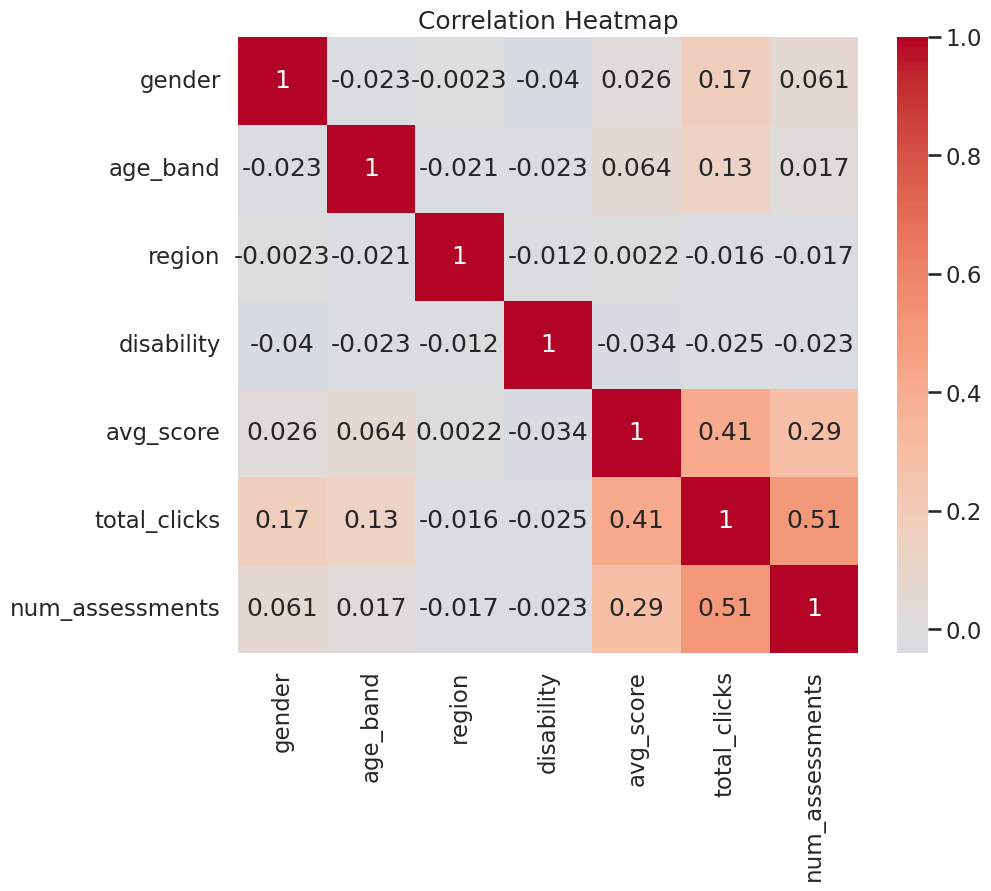

In [31]:
# CORRELATION HEATMAP
encoded_df = df.copy()
for var in demographic_vars:
    if encoded_df[var].dtype == 'object':
        encoded_df[var] = pd.Categorical(encoded_df[var]).codes

heatmap_vars = demographic_vars + ['avg_score', 'total_clicks', 'num_assessments']
corr = encoded_df[heatmap_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.savefig("RQ3_demographic_correlation_heatmap.png", dpi=300)
plt.show()

# RQ4
Can we predict how a student will perform at the end of the course based on their
learning behaviors, demographics, assessment performance, and registration patterns?

In [32]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

In [33]:
studentInfo = pd.read_csv("studentInfo.csv")
studentVle = pd.read_csv("studentVle.csv", on_bad_lines='skip', engine='python')
assessments = pd.read_csv("assessments.csv")
studentAssessment = pd.read_csv("studentAssessment.csv")
studentRegistration = pd.read_csv("studentRegistration.csv", on_bad_lines='skip', engine='python')

In [34]:
# Feature Engineering

# VLE behavioral features
vle_agg = studentVle.groupby("id_student").agg(
    total_clicks=("sum_click", "sum"),
    avg_clicks=("sum_click", "mean"),
    num_active_days=("date", "nunique")
).reset_index()

# Assessment features
assess_agg = studentAssessment.groupby("id_student").agg(
    avg_score=("score", "mean"),
    num_assessments=("score", "count")
).reset_index()

# Registration features
studentRegistration["date_unregistration"].fillna(
    studentRegistration["date_registration"].max(),
    inplace=True
)

studentRegistration["days_registered"] = (
    studentRegistration["date_unregistration"] - studentRegistration["date_registration"]
)

studentRegistration["is_unregistered"] = (
    studentRegistration["date_unregistration"] > 0
).astype(int)

reg_agg = studentRegistration.groupby("id_student").agg(
    days_registered=("days_registered", "mean"),
    late_registration=("date_registration", "min"),
    num_reg_records=("id_student", "count"),
    ever_unregistered=("is_unregistered", "max")
).reset_index()

In [35]:
# Merge everything
df = studentInfo.merge(vle_agg, on="id_student", how="left")
df = df.merge(assess_agg, on="id_student", how="left")
df = df.merge(reg_agg, on="id_student", how="left")

df.fillna({
    "total_clicks": 0,
    "avg_clicks": 0,
    "num_active_days": 0,
    "avg_score": 0,
    "num_assessments": 0,
    "days_registered": 0,
    "late_registration": df["late_registration"].min(),
    "num_reg_records": 0,
    "ever_unregistered": 0
}, inplace=True)

In [36]:
# Prepare X, y
y = df["final_result"]
X = df.drop(columns=["final_result", "id_student"])

# Encode categorical data
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].astype('category').cat.codes

# Encode target labels
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [37]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (Linear Kernel)": SVC(kernel="linear", probability=True, random_state=42)
}

# Store results
metrics_summary = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

Model: Logistic Regression
--------------------------------------------------------------------------------
Accuracy: 0.7422
Precision: 0.7283
Recall: 0.6605
F1 Score: 0.6808

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.36      0.47       756
           1       0.67      0.63      0.65      1763
           2       0.69      0.86      0.77      3091
           3       0.89      0.79      0.84      2539

    accuracy                           0.74      8149
   macro avg       0.73      0.66      0.68      8149
weighted avg       0.75      0.74      0.74      8149



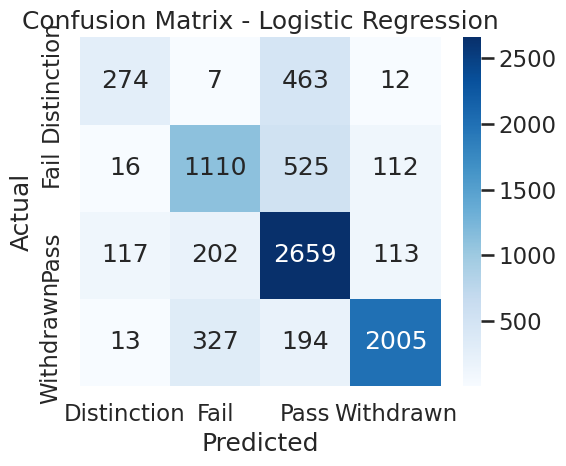

Model: Random Forest
--------------------------------------------------------------------------------
Accuracy: 0.7699
Precision: 0.7509
Recall: 0.6963
F1 Score: 0.7152

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.43      0.52       756
           1       0.72      0.66      0.69      1763
           2       0.73      0.88      0.80      3091
           3       0.89      0.82      0.85      2539

    accuracy                           0.77      8149
   macro avg       0.75      0.70      0.72      8149
weighted avg       0.77      0.77      0.77      8149



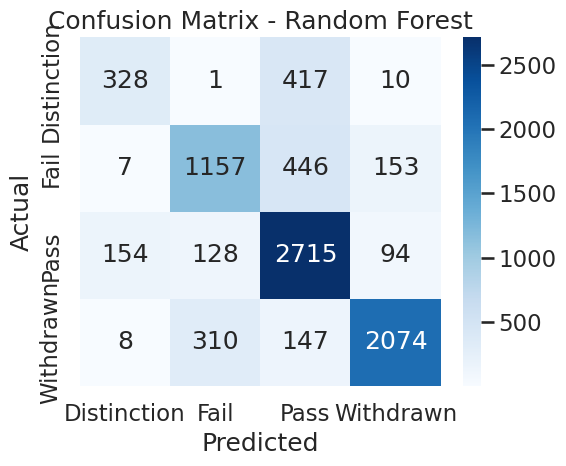

Model: SVM (Linear Kernel)
--------------------------------------------------------------------------------
Accuracy: 0.7440
Precision: 0.7299
Recall: 0.6580
F1 Score: 0.6787

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.35      0.45       756
           1       0.68      0.62      0.65      1763
           2       0.69      0.87      0.77      3091
           3       0.89      0.80      0.84      2539

    accuracy                           0.74      8149
   macro avg       0.73      0.66      0.68      8149
weighted avg       0.75      0.74      0.74      8149



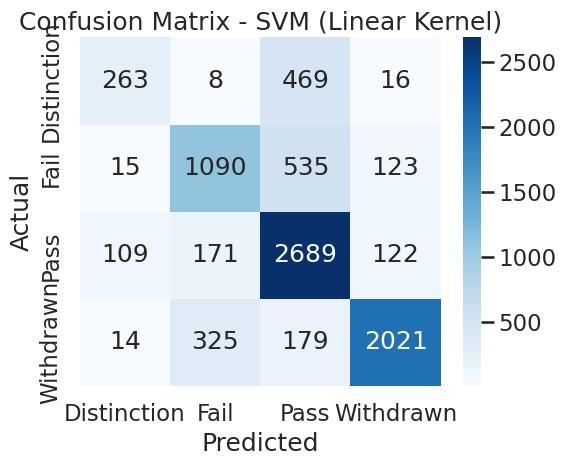

In [38]:
# Train nad Evaluate Models
for name, model in models.items():
    print(f"Model: {name}")
    print("-"*80)

    # Train
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    # Save for comparison
    metrics_summary["Model"].append(name)
    metrics_summary["Accuracy"].append(acc)
    metrics_summary["Precision"].append(prec)
    metrics_summary["Recall"].append(rec)
    metrics_summary["F1 Score"].append(f1)

    # Print results
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le_y.classes_,
                yticklabels=le_y.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"RQ4_confusion_matrix_{name.replace(' ', '_')}.png")
    plt.show()
    plt.close()

<Figure size 1400x600 with 0 Axes>

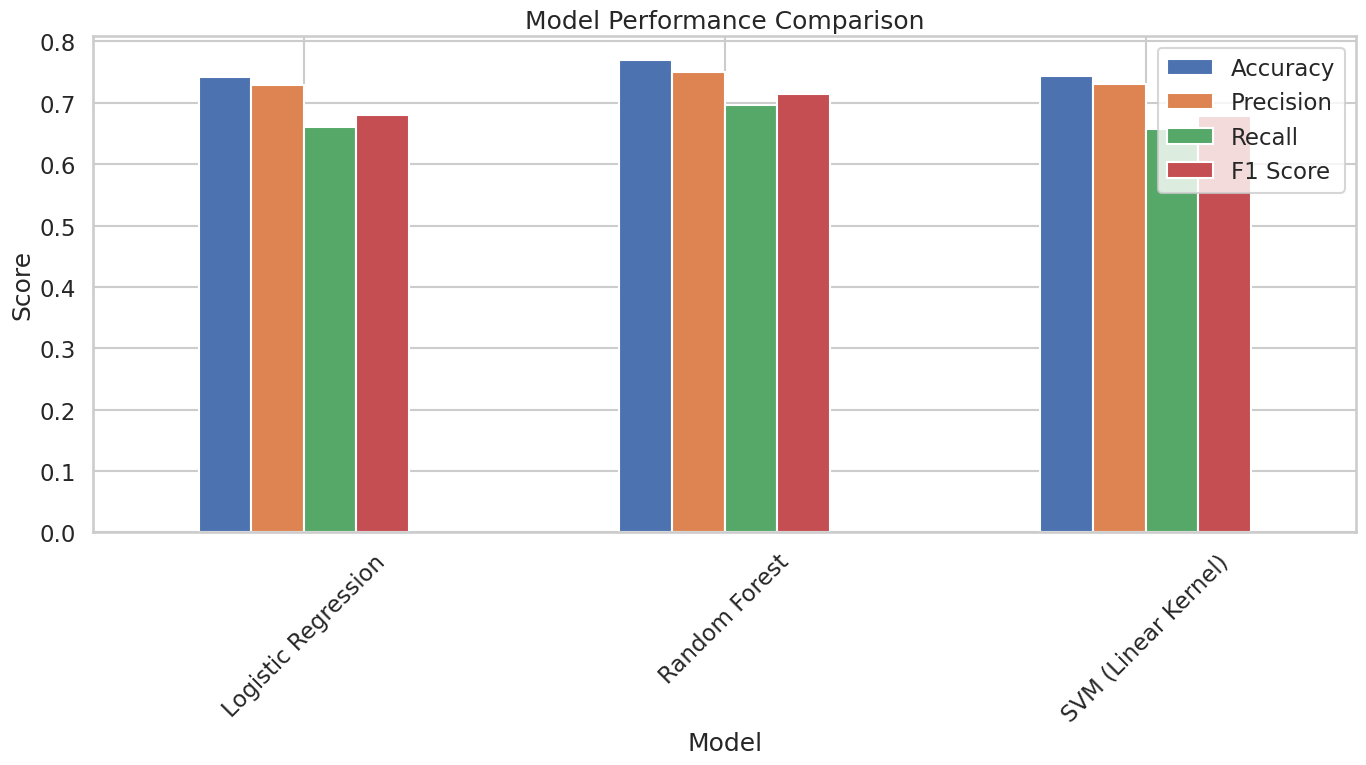

In [39]:
# Comparison Chart
metrics_df = pd.DataFrame(metrics_summary)
metrics_df.set_index("Model", inplace=True)

plt.figure(figsize=(14, 6))
metrics_df.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("RQ4_model_performance_comparison.png")
plt.show()
plt.close()

# RQ5
How effectively can the system detect behavioral outliers among university students, and what impact do these outliers have on clustering quality?

In [40]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    davies_bouldin_score, calinski_harabasz_score
)
from scipy import stats
import os

sns.set(style="whitegrid")

In [41]:
# File loading
studentInfo = pd.read_csv("studentInfo.csv", engine="python", on_bad_lines="skip")
studentVle = pd.read_csv("studentVle.csv", engine="python", on_bad_lines="skip")
studentAssessment = pd.read_csv("studentAssessment.csv", engine="python", on_bad_lines="skip")
studentRegistration = pd.read_csv("studentRegistration.csv", engine="python", on_bad_lines="skip")

In [42]:
# Feature engineering

# VLE features
vle_agg = studentVle.groupby("id_student").agg(
    total_clicks=("sum_click", "sum"),
    avg_clicks=("sum_click", "mean"),
    num_active_days=("date", "nunique")
).reset_index()

# Assessment features
assess_agg = studentAssessment.groupby("id_student").agg(
    avg_score=("score", "mean"),
    num_assessments=("score", "count")
).reset_index()

# Registration features
# Fill missing unregistration dates with max registration date
studentRegistration["date_unregistration"].fillna(
    studentRegistration["date_registration"].max(),
    inplace=True
)

try:
    studentRegistration["days_registered"] = (
        studentRegistration["date_unregistration"] - studentRegistration["date_registration"]
    )
except Exception:
    # If dates are strings, try converting to numeric
    studentRegistration["days_registered"] = pd.to_numeric(studentRegistration["date_unregistration"], errors="coerce") - \
                                            pd.to_numeric(studentRegistration["date_registration"], errors="coerce")

studentRegistration["is_unregistered"] = (studentRegistration["date_unregistration"] > studentRegistration["date_registration"]).astype(int)

reg_agg = studentRegistration.groupby("id_student").agg(
    days_registered=("days_registered", "mean"),
    late_registration=("date_registration", "min"),
    num_reg_records=("id_student", "count"),
    ever_unregistered=("is_unregistered", "max")
).reset_index()

In [43]:
# Merge everything
df = studentInfo.merge(vle_agg, on="id_student", how="left")
df = df.merge(assess_agg, on="id_student", how="left")
df = df.merge(reg_agg, on="id_student", how="left")

# Fill NA defaults
df.fillna({
    "total_clicks": 0,
    "avg_clicks": 0,
    "num_active_days": 0,
    "avg_score": 0,
    "num_assessments": 0,
    "days_registered": 0,
    "late_registration": df["late_registration"].min() if "late_registration" in df.columns else 0,
    "num_reg_records": 0,
    "ever_unregistered": 0
}, inplace=True)

# Keep only numeric features for outlier detection and clustering
num_features = [
    "total_clicks", "avg_clicks", "num_active_days",
    "avg_score", "num_assessments",
    "days_registered", "late_registration",
    "num_reg_records", "ever_unregistered"
]
# ensure all present
num_features = [f for f in num_features if f in df.columns]

num_df = df[num_features].copy()

# Save a copy for distribution plots
X_df = num_df.copy()

In [44]:
# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values)

print("Feature engineering & scaling done. n_samples =", X_scaled.shape[0])

Feature engineering & scaling done. n_samples = 32593


In [45]:
# KMeans clustering BEFORE outlier removal
k = 4
kmeans_before = KMeans(n_clusters=k, random_state=42)
labels_before = kmeans_before.fit_predict(X_scaled)

# Compute metrics BEFORE
sil_before = silhouette_score(X_scaled, labels_before) if len(set(labels_before)) > 1 else np.nan
dbi_before = davies_bouldin_score(X_scaled, labels_before) if len(set(labels_before)) > 1 else np.nan
chi_before = calinski_harabasz_score(X_scaled, labels_before) if len(set(labels_before)) > 1 else np.nan

print("\n Clustering Quality BEFORE Outlier Removal")
print("-"*80)
print("Silhouette Score:", sil_before)
print("Davies-Bouldin Index:", dbi_before)
print("Calinski-Harabasz Index:", chi_before)


 Clustering Quality BEFORE Outlier Removal
--------------------------------------------------------------------------------
Silhouette Score: 0.2807713862894347
Davies-Bouldin Index: 1.0929511491201793
Calinski-Harabasz Index: 10774.96522661017


In [46]:
# Outlier detection

# DBSCAN noise
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)
dbscan_outliers = (db_labels == -1)

# Z-score method (threshold = 3)
z_scores = np.abs(stats.zscore(X_scaled, axis=0, nan_policy='omit'))
z_outliers = (z_scores > 3).any(axis=1)

# IQR method on scaled data
Q1 = np.percentile(X_scaled, 25, axis=0)
Q3 = np.percentile(X_scaled, 75, axis=0)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
iqr_outliers = ((X_scaled < lower) | (X_scaled > upper)).any(axis=1)

# Counts
print("\nDBSCAN Outliers Detected:", int(dbscan_outliers.sum()))
print("Z-score Outliers Detected:", int(z_outliers.sum()))
print("IQR Outliers Detected:", int(iqr_outliers.sum()))

# Union of methods
combined_outliers = dbscan_outliers | z_outliers | iqr_outliers
n_outliers = int(combined_outliers.sum())
print("Total Unique Outliers Detected (union):", n_outliers)


DBSCAN Outliers Detected: 262
Z-score Outliers Detected: 1934
IQR Outliers Detected: 14443
Total Unique Outliers Detected (union): 14444


In [47]:
# Clustering AFTER outlier removal
# Remove outliers from scaled data
X_no_out = X_scaled[~combined_outliers]

# KMeans on cleaned data
kmeans_after = KMeans(n_clusters=k, random_state=42)
labels_after = kmeans_after.fit_predict(X_no_out)

# Compute metrics AFTER
sil_after = silhouette_score(X_no_out, labels_after) if len(set(labels_after)) > 1 else np.nan
dbi_after = davies_bouldin_score(X_no_out, labels_after) if len(set(labels_after)) > 1 else np.nan
chi_after = calinski_harabasz_score(X_no_out, labels_after) if len(set(labels_after)) > 1 else np.nan

print("\n Clustering Quality AFTER Outlier Removal")
print("-"*80)
print("Silhouette Score:", sil_after)
print("Davies-Bouldin Index:", dbi_after)
print("Calinski-Harabasz Index:", chi_after)


 Clustering Quality AFTER Outlier Removal
--------------------------------------------------------------------------------
Silhouette Score: 0.2025156061690691
Davies-Bouldin Index: 1.4456098018722123
Calinski-Harabasz Index: 5589.4590291062805


In [48]:
# ARI & NMI comparing same points (before vs after)
labels_before_clean = labels_before[~combined_outliers]
ari_before_after = adjusted_rand_score(labels_before_clean, labels_after)
nmi_before_after = normalized_mutual_info_score(labels_before_clean, labels_after)

print("\n Agreement Between BEFORE and AFTER (on non-outlier points)")
print("-"*80)
print("ARI (before vs after, non-outliers):", ari_before_after)
print("NMI (before vs after, non-outliers):", nmi_before_after)


 Agreement Between BEFORE and AFTER (on non-outlier points)
--------------------------------------------------------------------------------
ARI (before vs after, non-outliers): 0.0893473055867094
NMI (before vs after, non-outliers): 0.2224689223191186


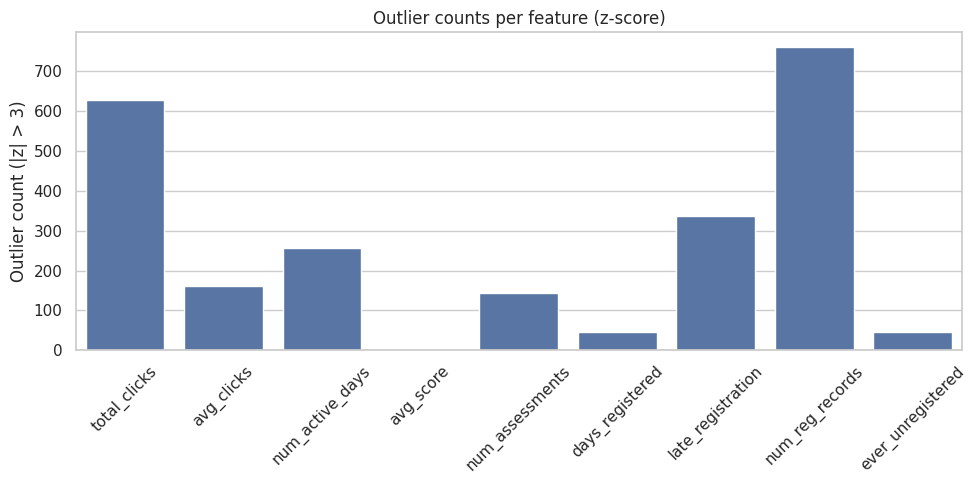

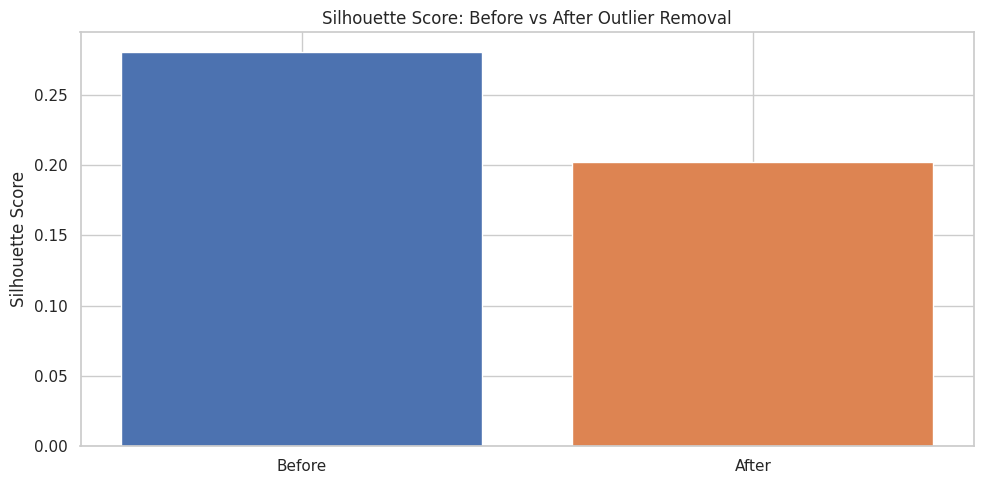

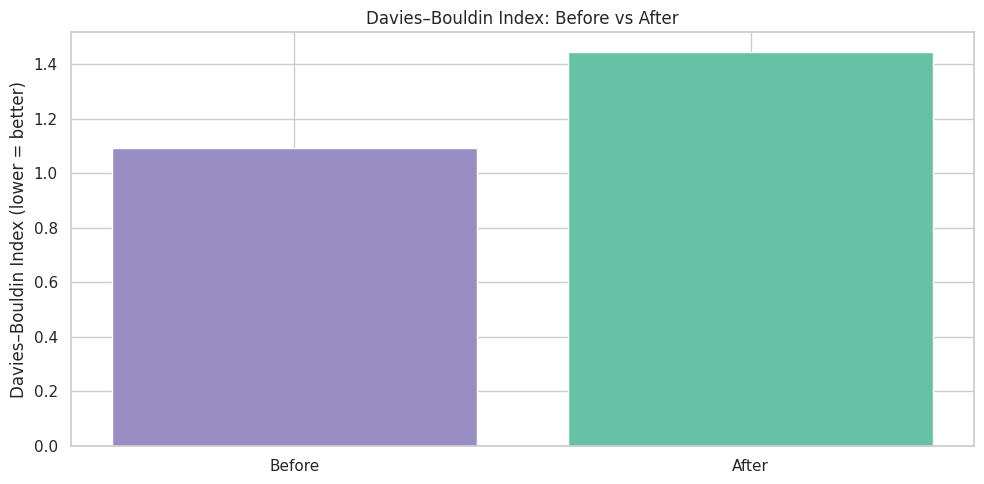

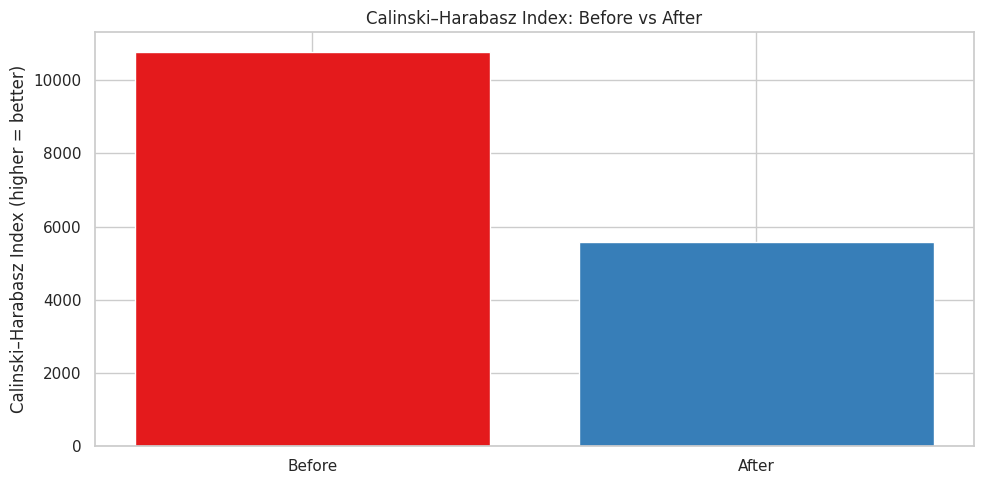

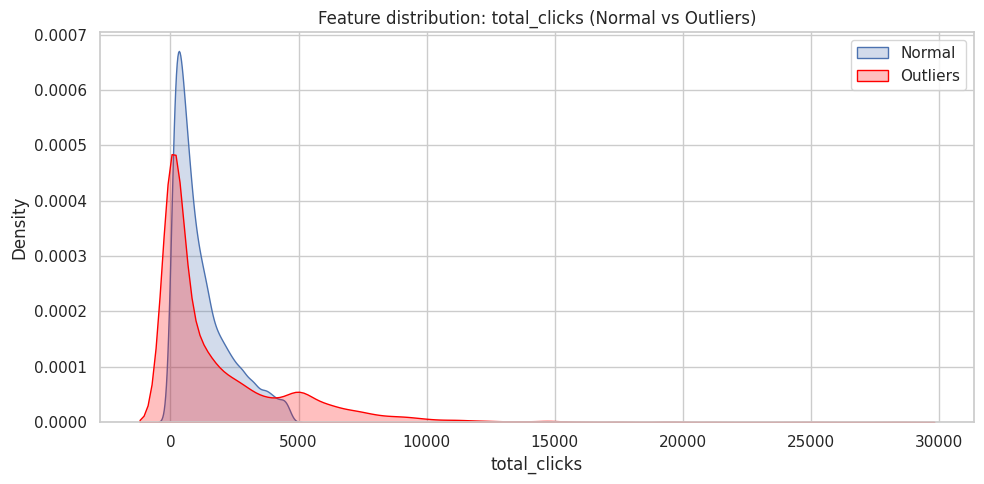

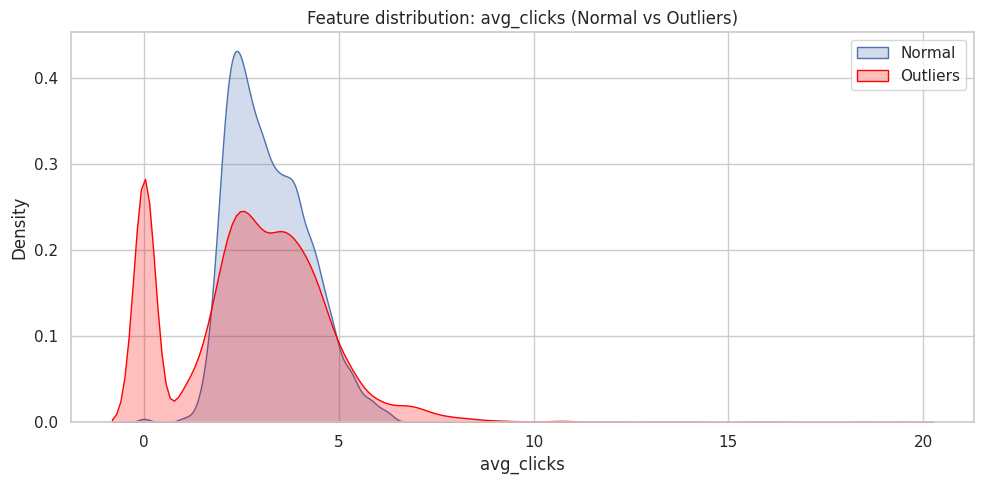

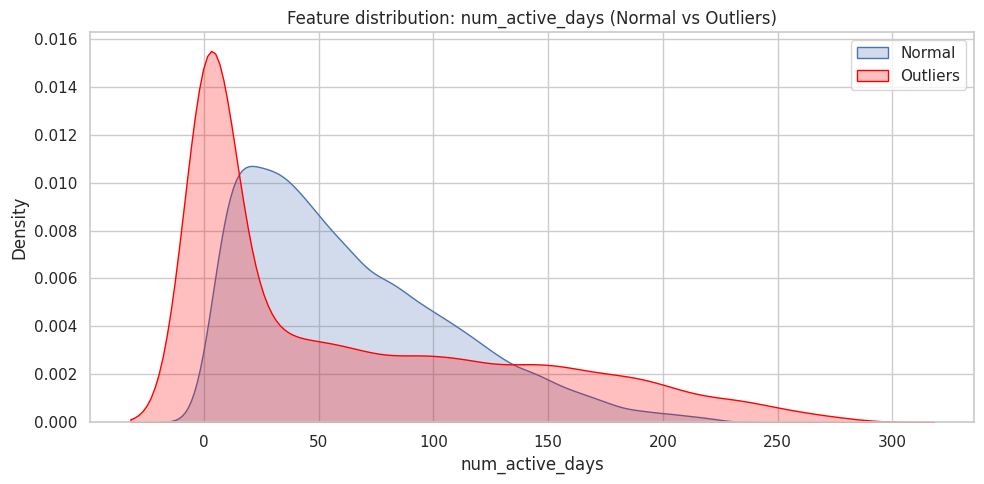

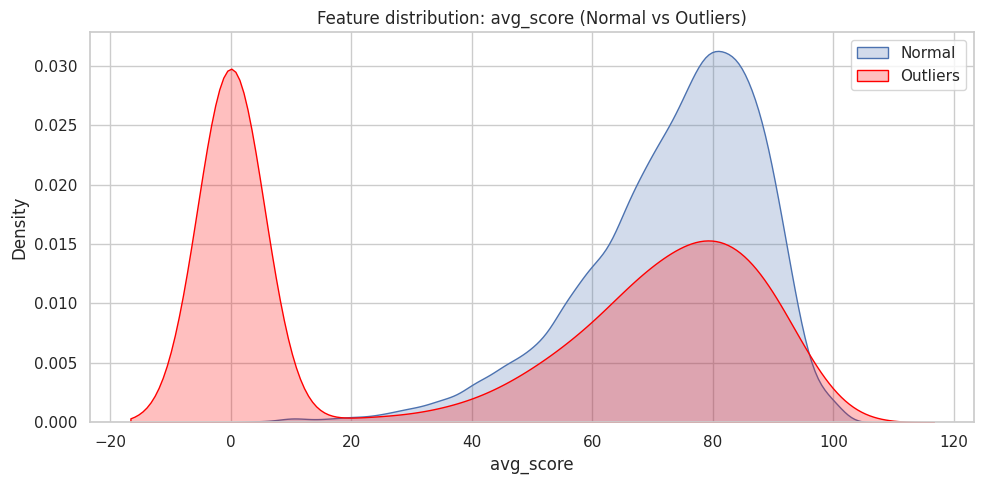

In [49]:
# Plot 1: Outlier distribution across features
per_feature_outliers = (z_scores > 3).sum(axis=0)  # counts per feature (z-score based)
plt.figure(figsize=(10, 5))
sns.barplot(x=num_features, y=per_feature_outliers)
plt.xticks(rotation=45)
plt.ylabel("Outlier count (|z| > 3)")
plt.title("Outlier counts per feature (z-score)")
plt.tight_layout()
plt.savefig(f"RQ5_outlier_distribution.png")
plt.show()

# Plot 2: Silhouette score comparison (before vs after)
plt.figure(figsize=(10, 5))
plt.bar(["Before", "After"], [sil_before, sil_after], color=["#4c72b0", "#dd8452"])
plt.title("Silhouette Score: Before vs After Outlier Removal")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(f"RQ5_silhouette_comparison.png")
plt.show()

# Plot 3: Davies–Bouldin Index comparison
plt.figure(figsize=(10, 5))
plt.bar(["Before", "After"], [dbi_before, dbi_after], color=["#998ec3", "#66c2a5"])
plt.title("Davies–Bouldin Index: Before vs After")
plt.ylabel("Davies–Bouldin Index (lower = better)")
plt.tight_layout()
plt.savefig(f"RQ5_davies_bouldin_comparison.png")
plt.show()

# Plot 4: Calinski–Harabasz Index comparison
plt.figure(figsize=(10, 5))
plt.bar(["Before", "After"], [chi_before, chi_after], color=["#e41a1c", "#377eb8"])
plt.title("Calinski–Harabasz Index: Before vs After")
plt.ylabel("Calinski–Harabasz Index (higher = better)")
plt.tight_layout()
plt.savefig(f"RQ5_calinski_harabasz_comparison.png")
plt.show()


# Plot 5: Feature distributions for outliers vs normal
selected_features = [f for f in ["total_clicks", "avg_clicks", "num_active_days", "avg_score"] if f in num_features]

for feat in selected_features:
    plt.figure(figsize=(10, 5))
    try:
        sns.kdeplot(X_df.loc[~combined_outliers, feat], label="Normal", fill=True)
        sns.kdeplot(X_df.loc[combined_outliers, feat], label="Outliers", fill=True, color="red")
    except Exception:
        plt.hist(X_df.loc[~combined_outliers, feat], bins=50, alpha=0.6, label="Normal")
        plt.hist(X_df.loc[combined_outliers, feat], bins=50, alpha=0.6, label="Outliers", color="red")
    plt.title(f"Feature distribution: {feat} (Normal vs Outliers)")
    plt.xlabel(feat)
    plt.legend()
    plt.tight_layout()
    fname = f"RQ5_feature_distribution_{feat}.png"
    plt.savefig(fname)
    plt.show()
